In [1]:
from matplotlib import pyplot as plt
from whar_datasets import (
    get_dataset_cfg,
    WHARDatasetID,
    PostProcessingPipeline,
    PreProcessingPipeline,
    Loader,
    LOSOSplitter,
    KFoldSplitter,
    LGSOSplitter,
    LKSOSplitter,
)

In [2]:
cfg = get_dataset_cfg(WHARDatasetID.WISDM)

cfg.parallelize = True
cfg.in_memory = False
cfg.cache_each_split = False
cfg.num_folds = 10

force_recompute = False
# force_recompute = [False, False, True, True]

In [3]:
pre_pipeline = PreProcessingPipeline(cfg)
activity_df, session_df, window_df = pre_pipeline.run(force_recompute)

2026-06-09 17:27:32,527 - whar-datasets - INFO - Running DownloadingStep
2026-06-09 17:27:32,528 - whar-datasets - INFO - Checking hash for DownloadingStep
2026-06-09 17:27:32,529 - whar-datasets - INFO - Hash is up to date
2026-06-09 17:27:32,529 - whar-datasets - INFO - Running ExtractingStep
2026-06-09 17:27:32,530 - whar-datasets - INFO - Checking hash for ExtractingStep
2026-06-09 17:27:32,531 - whar-datasets - INFO - Hash is up to date
2026-06-09 17:27:32,531 - whar-datasets - INFO - Running ParsingStep
2026-06-09 17:27:32,532 - whar-datasets - INFO - Checking hash for ParsingStep
2026-06-09 17:27:32,533 - whar-datasets - INFO - Hash is up to date
2026-06-09 17:27:32,533 - whar-datasets - INFO - Running WindowingStep
2026-06-09 17:27:32,533 - whar-datasets - INFO - Checking hash for WindowingStep
2026-06-09 17:27:32,534 - whar-datasets - INFO - Hash is up to date
2026-06-09 17:27:32,535 - whar-datasets - INFO - Loading windowing
2026-06-09 17:27:32,552 - whar-datasets - INFO - Se

In [4]:
splitter = LKSOSplitter(cfg)
# splitter = LGSOSplitter(cfg)
# splitter = KFoldSplitter(cfg)

splits = splitter.get_splits(session_df, window_df)
for split in splits:
    print(
        split.identifier,
        len(split.train_indices),
        len(split.val_indices),
        len(split.test_indices),
    )

group_kfold_0 14792 3698 1862
group_kfold_1 14397 3599 2356
group_kfold_2 14041 3510 2801
group_kfold_3 14388 3597 2367
group_kfold_4 14069 3517 2766
group_kfold_5 14616 3653 2083
group_kfold_6 15066 3766 1520
group_kfold_7 15230 3807 1315
group_kfold_8 15093 3773 1486
group_kfold_9 14845 3711 1796


In [5]:
splitter = LKSOSplitter(cfg)
# splitter = LGSOSplitter(cfg)
# splitter = KFoldSplitter(cfg)

splits = splitter.get_splits(session_df, window_df)
for split in splits:
    print(
        split.identifier,
        len(split.train_indices),
        len(split.val_indices),
        len(split.test_indices),
    )

group_kfold_0 14792 3698 1862
group_kfold_1 14397 3599 2356
group_kfold_2 14041 3510 2801
group_kfold_3 14388 3597 2367
group_kfold_4 14069 3517 2766
group_kfold_5 14616 3653 2083
group_kfold_6 15066 3766 1520
group_kfold_7 15230 3807 1315
group_kfold_8 15093 3773 1486
group_kfold_9 14845 3711 1796


In [6]:
post_pipeline = PostProcessingPipeline(
    cfg, pre_pipeline, window_df, splits[0].train_indices
)
samples = post_pipeline.run(False)

2026-06-09 17:27:32,666 - whar-datasets - INFO - Running SamplingStep
2026-06-09 17:27:32,666 - whar-datasets - INFO - Checking hash for SamplingStep
2026-06-09 17:27:32,669 - whar-datasets - INFO - Hash is up to date


In [7]:
loader = Loader(activity_df, session_df, window_df, post_pipeline.samples_dir, samples)
print(len(loader))

20352


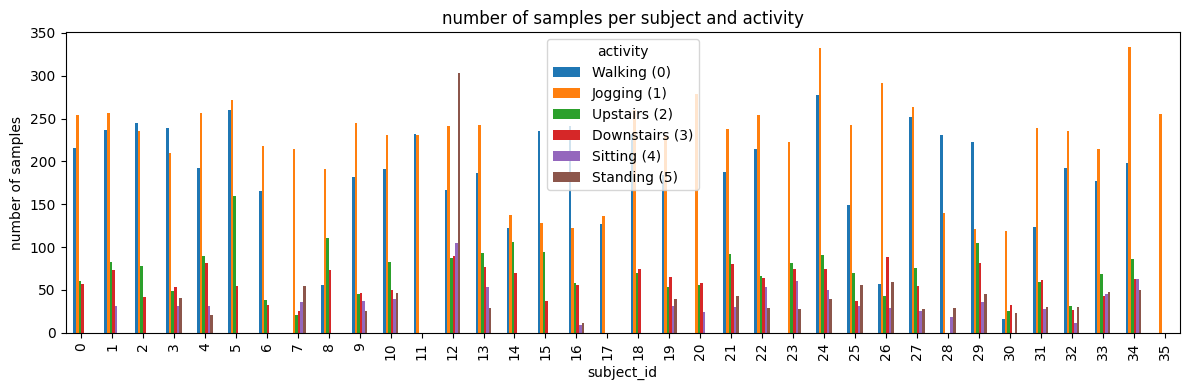

In [8]:
len(loader)
loader.plot_indices_statistics(list(range(len(loader))))

Text(0.5, 1.0, ' Activity: 5, Subject: 29')

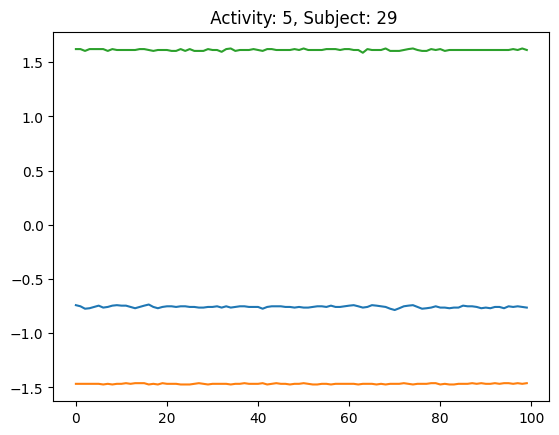

In [9]:
subject_id = None
activity_id = None

# index as ra
ya, ys, (x,) = loader.sample_items(1, activity_id=activity_id, subject_id=subject_id)
ya_single = ya[0]
ys_single = ys[0]
x_single = x[0]

plt.plot(x_single)
plt.title(f" Activity: {ya_single}, Subject: {ys_single}")